# Imports

Treasury: DGS10
S&P500: SP500
Bitcoin: Close

In [20]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import uniform_filter1d

from statsmodels.tsa.stattools import adfuller, acf, pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Optional if installed
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except Exception:
    ARCH_AVAILABLE = False

# Optional for deep models
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import TCN, Autoformer
    from neuralforecast.losses.pytorch import MAE
    NF_AVAILABLE = True
except Exception:
    NF_AVAILABLE = False

In [14]:
# ============================================================
# 1. Data loading
# ============================================================
def load_data(name,start_date='2021-01-01'):
    if name == "BTC":
        bitcoin_close = "bitcoin_close.csv"
        data = pd.read_csv(f'./data/processed/{bitcoin_close}', parse_dates=["date"])
        data = data[data["date"] >= start_date]
        data= pd.Series(data['btc_close'].values, index=data['date'])
    elif name == "SP500":
        SP500 = "sp500_cleaned.csv"
        data = pd.read_csv(f'./data/processed/{SP500}', parse_dates=["date"])
        data = data[data["date"] >= start_date]
        data= pd.Series(data['sp500'].values, index=data['date'])
    elif name == "FRED":
        FRED = "treasury_dgs10.csv"
        data = pd.read_csv(f'./data/processed/{FRED}', parse_dates=["date"])
        data = data[data["date"] >= start_date]
        data= pd.Series(data['dgs10'].values, index=data['date'])
    else:
        raise ValueError("Unsupported dataset name. Use 'BTC', 'SP500', or 'FRED'.")
    return data


# ============================================================
# 2. Helper functions
# ============================================================
def train_test_split_ts(series, test_size=0.2):
    n = len(series)
    split_idx = int(n * (1 - test_size))
    train = series.iloc[:split_idx].copy()
    test = series.iloc[split_idx:].copy()
    return train, test

def accuracy_metrics(y_true, y_pred, label="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    bias = np.mean(y_pred - y_true)
    pm = np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)
    
    print(f"{label} MSE:   {mse:.4f}")
    print(f"{label} RMSE:  {rmse:.4f}")
    print(f"{label} MAE:   {mae:.4f}")
    print(f"{label} MAPE:  {mape:.4f}%")
    print(f"{label} Bias:  {bias:.4f}")
    print(f"{label} PM:    {pm:.4f}")
    print()

    return {
        "Model": label,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "Bias": bias,
        "PM": pm
    }

def rolling_mean_vol(series, window=30):
    values = np.asarray(series, dtype=float)

    roll_mean = uniform_filter1d(values, size=window, mode="nearest")

    sq_mean = uniform_filter1d(values**2, size=window, mode="nearest")
    roll_var = sq_mean - roll_mean**2
    roll_var = np.maximum(roll_var, 0)
    roll_std = np.sqrt(roll_var)

    out = pd.DataFrame(index=series.index)
    out["value"] = series
    out["roll_mean"] = roll_mean
    out["roll_std"] = roll_std
    return out

def horizonwise_errors(y_true_mat, y_pred_mat):
    """
    y_true_mat, y_pred_mat: arrays shape (n_windows, h)
    """
    h = y_true_mat.shape[1]
    rows = []
    for j in range(h):
        err = y_pred_mat[:, j] - y_true_mat[:, j]
        rows.append({
            "horizon": j + 1,
            "bias": np.mean(err),
            "var_error": np.var(err),
            "mae": np.mean(np.abs(err)),
            "rmse": np.sqrt(np.mean(err ** 2))
        })
    return pd.DataFrame(rows)

In [23]:
DATA_SET = "BTC"
df = load_data(DATA_SET)

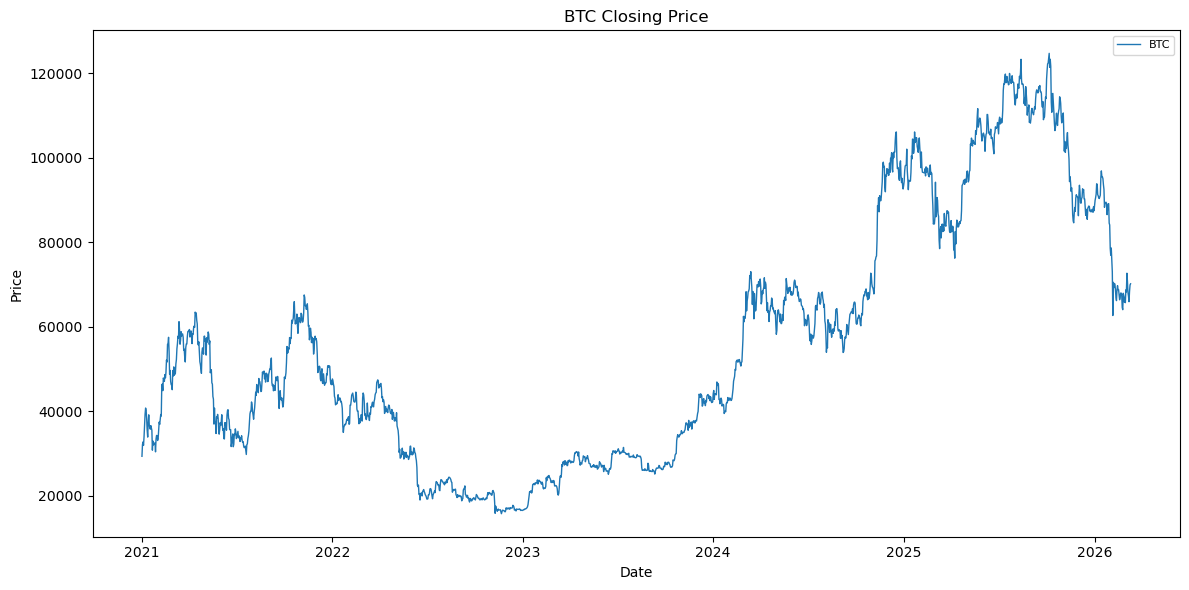

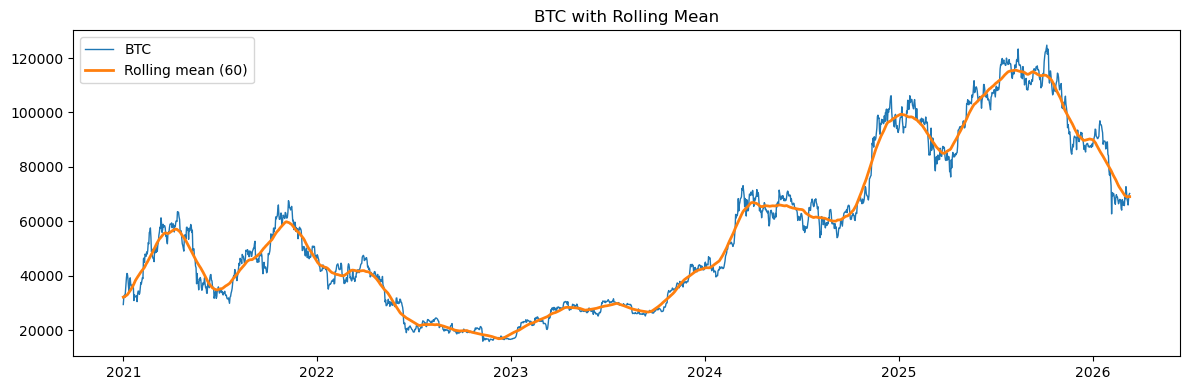

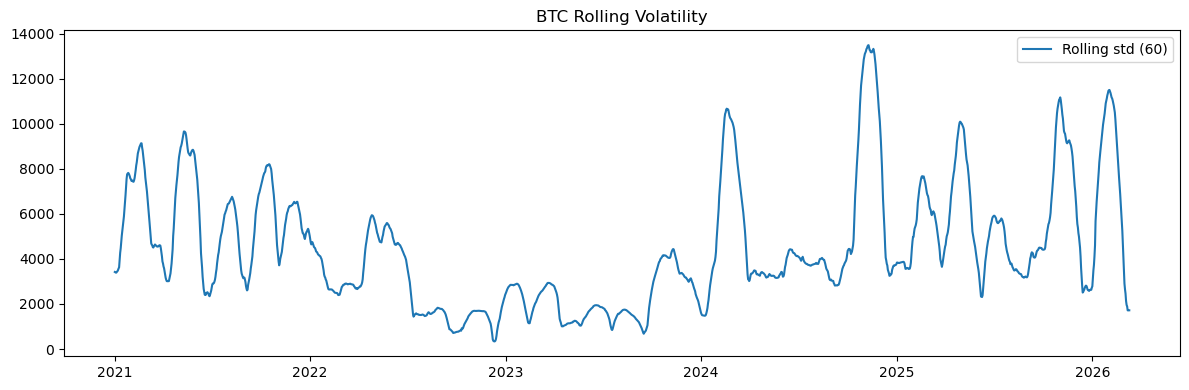

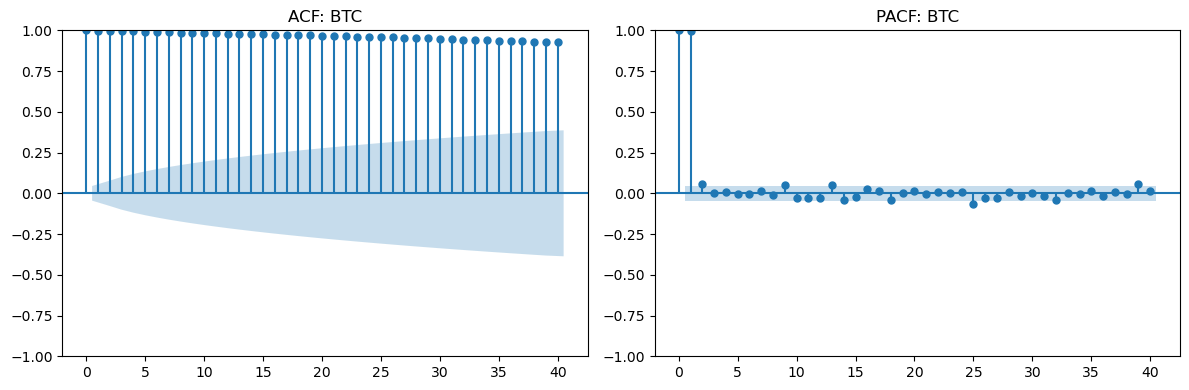

ADF on level:
{'stat': np.float64(-1.2476492747535821), 'pvalue': np.float64(0.6527699294792249)}
ADF on first difference:
{'stat': np.float64(-45.82505295875335), 'pvalue': 0.0}


In [24]:
# ============================================================
# 3. EDA
# ============================================================
plt.figure(figsize=(12, 6))
plt.plot(df, label=DATA_SET, linewidth=1)
plt.title("BTC Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

rmv = rolling_mean_vol(df, window=60)

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["value"], label=DATA_SET, linewidth=1)
plt.plot(rmv.index, rmv["roll_mean"], label="Rolling mean (60)", linewidth=2)
plt.title("BTC with Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["roll_std"], label="Rolling std (60)", linewidth=1.5)
plt.title("BTC Rolling Volatility")
plt.legend()
plt.tight_layout()
plt.show()

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df, lags=40, ax=axes[0])
plot_pacf(df, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF: BTC")
axes[1].set_title("PACF: BTC")
plt.tight_layout()
plt.show()

# First difference for stationarity check
dseries = df.diff().dropna()

adf_level = adfuller(df.dropna())
adf_diff = adfuller(dseries)

print("ADF on level:")
print({"stat": adf_level[0], "pvalue": adf_level[1]})
print("ADF on first difference:")
print({"stat": adf_diff[0], "pvalue": adf_diff[1]})